## Workings out

<img src="IMG_5261.png" width="300">
<img src="IMG_5262.png" width="300">
<img src="IMG_5263.png" width="300">
<img src="IMG_5264.png" width="300">
<img src="IMG_5265.png" width="300">

## Section 1:

To simulate the harmonic motion of a guitar string we would need to apply the wave equation across the x axis over time.

The wave equation is:

$$\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}$$

To derive an analytical solution to this equation we would need to separate the variables and approximate using the 'Fourier Series'

We first make the 'Ansatz': $u(x,t)$ is equal to some function of $x$ and some function of $t$, i.e. $u(x,t) = F(x)G(t)$

We subtitute that into the wave equation:

$$\frac{\partial^2 F(x)G(t)}{\partial t^2} = c^2 \frac{\partial^2 F(x)G(t)}{\partial x^2}.$$

And differentiate and rearrange to get only terms of $G(t)$ on one side and $F(x)$ on the other for:

$$\frac{F''(x)}{F(x)} = c^2 \frac{G''(t)}{G(t)}.$$

For this equation to hold true when the sides do not share any terms, they must be equal to some constant. We will call this constant $-\lambda^2$.

To solve each side for $F$ and $G$ we get the following:

$$
\frac{F''(x)}{F} = -\lambda^2\\

F''(x) = -\lambda^2F
$$



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim

In [12]:
#Variables
#String information based on E-1 Extra Light Strings sourced from https://global.elixirstrings.com/support/string-tension-for-tuning-guitar
L = 1 #length of the string
a = L/2 #the point where the string is plucked (halfway)
h = 0.01 #height of the string at a (metres)
T = 71.17 #tension in Newtons
r = 0.005 #radius of string
density = 7850 #density of string kg/m^3
time_step = 500 #step size/time period
time = 0.01 #length of time (seconds)
roe = density * np.pi * r**2 #Linear Density of the string (kg/m)
c = np.sqrt(T/roe) #wave speed m/s
N = 100 #number of steps


#Arrays
n = np.arange(1, N+1) #array of harmonics
t = np.arange(0, time, time_step) #time
x = np.linspace(0, L, N) #array for positions along guitat string
u = np.zeros((len(x), len(t))) #array of displacement at t

In [13]:
#Soltuions

for i in range (N):
    An = (2 * h * L**2 * np.sin((n[i] * np.pi * a) / L)) / (n[i]**2 * np.pi**2 * a * ( L - a)) #fourier coefficient
    for j in range (len(t)): #iterates over time not N
        u[:, j] += An * np.sin((n[i] * np.pi * x) / L) * np.cos((n[i] * np.pi * c * t[j]) / L) #general solution

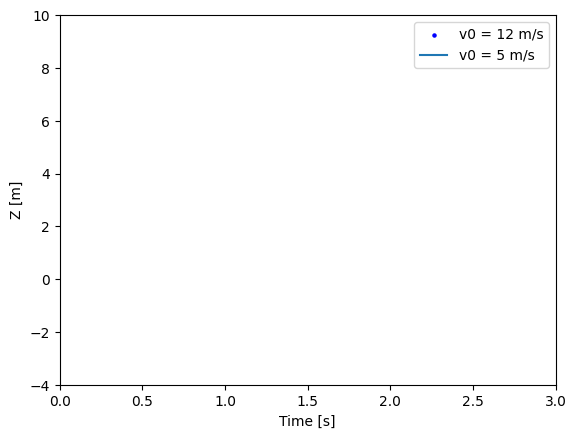

In [9]:
##Sample animated graph for documentation
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)
g = -9.81
v0 = 12
z = g * t**2 / 2 + v0 * t

v02 = 5
z2 = g * t**2 / 2 + v02 * t

scat = ax.scatter(t[0], z[0], c="b", s=5, label=f'v0 = {v0} m/s')
line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=[0, 3], ylim=[-4, 10], xlabel='Time [s]', ylabel='Z [m]')
ax.legend()


def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


plt.rcParams['animation.html'] = 'jshtml'
ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
ani